In [ ]:
# Import necessary libraries
import pandas as pd

# Load the dataset
# https://www2.census.gov/programs-surveys/acs/data/pums/2023/5-Year/
# 17 is Illinois
file_path = "psam_p17.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info()

# Display the first few rows to understand the structure
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623757 entries, 0 to 623756
Columns: 286 entries, RT to PWGTP80
dtypes: float64(84), int64(198), object(4)
memory usage: 1.3+ GB


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2019GQ0000131,3,1,3153,2,17,1207712,8,19,...,16,16,15,1,8,9,15,1,8,1
1,P,2019GQ0000140,3,1,1902,2,17,1207712,31,18,...,60,5,4,30,31,32,31,59,5,57
2,P,2019GQ0000164,3,1,9703,2,17,1207712,34,22,...,68,0,0,36,30,40,34,75,1,72
3,P,2019GQ0000232,3,1,3163,2,17,1207712,3,64,...,4,3,0,4,7,1,0,7,3,7
4,P,2019GQ0000236,3,1,3107,2,17,1207712,1,53,...,1,0,1,1,1,1,1,1,1,0


Income: PINCP (Total personal income)
Homeownership: This dataset appears to be person-level (psam_p02), so homeownership details might be in a separate housing dataset. However, SERIALNO can help link to housing information if available.
Region: REGION, STATE, PUMA (Public Use Microdata Area)
Household Size: NOP (Number of persons in household)
House Type (Bedrooms/Bathrooms): This data may be in a separate household dataset.

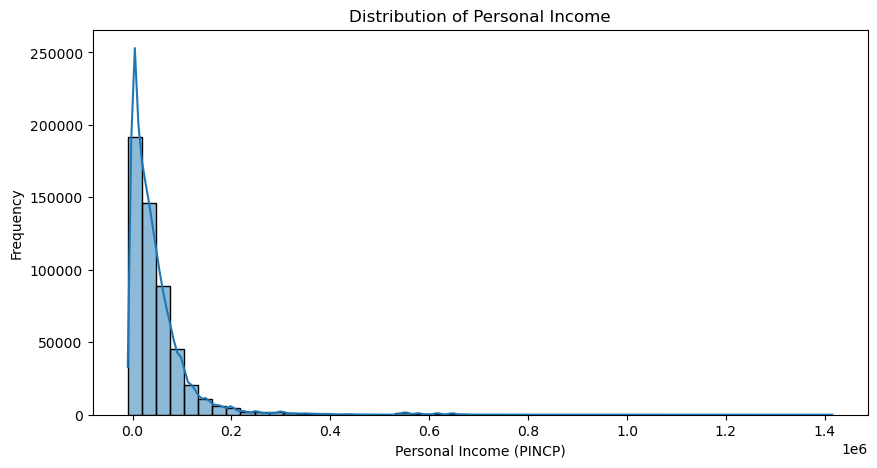

count    5.247710e+05
mean     4.944437e+04
std      7.251577e+04
min     -9.600000e+03
25%      1.000000e+04
50%      3.060000e+04
75%      6.300000e+04
max      1.415000e+06
Name: PINCP, dtype: float64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics for income (PINCP)
income_summary = df["PINCP"].describe()

# Plot income distribution
plt.figure(figsize=(10,5))
sns.histplot(df["PINCP"].dropna(), bins=50, kde=True)
plt.xlabel("Personal Income (PINCP)")
plt.ylabel("Frequency")
plt.title("Distribution of Personal Income")
plt.show()

# Display summary statistics
income_summary


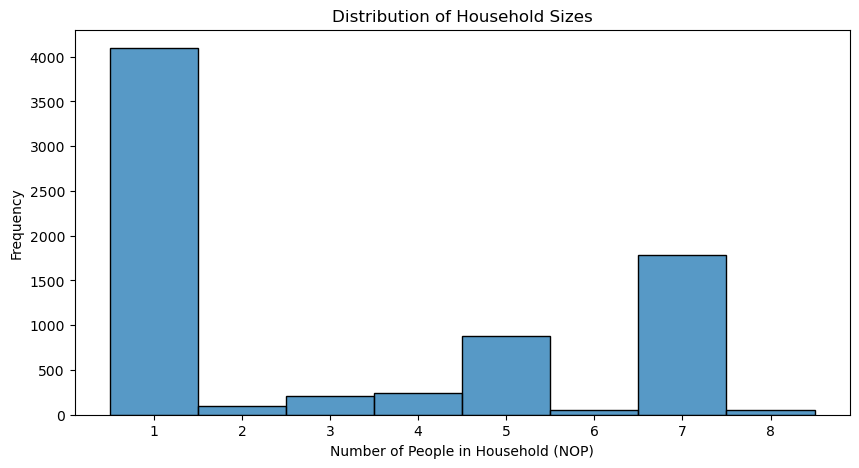

count    7424.000000
mean        3.171875
std         2.605931
min         1.000000
25%         1.000000
50%         1.000000
75%         6.000000
max         8.000000
Name: NOP, dtype: float64

In [23]:
# Check household size distribution (NOP)
if "NOP" in df.columns:
    household_size_summary = df["NOP"].describe()

    # Plot household size distribution
    plt.figure(figsize=(10,5))
    sns.histplot(df["NOP"].dropna(), bins=20, discrete=True)
    plt.xlabel("Number of People in Household (NOP)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Household Sizes")
    plt.show()

    # Display summary statistics
    household_size_summary
else:
    household_size_summary = "NOP column not found in the dataset."

household_size_summary


In [32]:
# Load the housing dataset
housing_file_path = "psam_h17.csv"
df_housing = pd.read_csv(housing_file_path)

# Check if SERIALNO exists in both datasets
serialno_in_both = "SERIALNO" in df.columns and "SERIALNO" in df_housing.columns

# Display the result
serialno_in_both


True

Homeownership (TEN) trends by income.
Number of bedrooms (BDSP) and household size (NOP).
Regional variations in homeownership.

In [33]:
# Identify relevant columns from the housing dataset
relevant_housing_cols = ["SERIALNO", "TEN", "BDSP", "RMSP"]  # TEN (Tenure: Ownership/Rent), BDSP (Bedrooms), RMSP (Total Rooms)

# Load only relevant columns from the housing dataset
df_housing = pd.read_csv(housing_file_path, usecols=relevant_housing_cols)

# Merge with personal dataset using SERIALNO
df_merged = df.merge(df_housing, on="SERIALNO", how="left")

# Display basic info after merging
df_merged.info()

# Display first few rows to confirm the merge
df_merged.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623757 entries, 0 to 623756
Columns: 289 entries, RT to TEN
dtypes: float64(87), int64(198), object(4)
memory usage: 1.3+ GB


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80,BDSP,RMSP,TEN
0,P,2019GQ0000131,3,1,3153,2,17,1207712,8,19,...,1,8,9,15,1,8,1,NaN,NaN,NaN
1,P,2019GQ0000140,3,1,1902,2,17,1207712,31,18,...,30,31,32,31,59,5,57,NaN,NaN,NaN
2,P,2019GQ0000164,3,1,9703,2,17,1207712,34,22,...,36,30,40,34,75,1,72,NaN,NaN,NaN
3,P,2019GQ0000232,3,1,3163,2,17,1207712,3,64,...,4,7,1,0,7,3,7,NaN,NaN,NaN
4,P,2019GQ0000236,3,1,3107,2,17,1207712,1,53,...,1,1,1,1,1,1,0,NaN,NaN,NaN


/var/folders/cr/d024fnbj3kl4z95bzjt7267h0000gn/T/ipykernel_96860/607815766.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_homeowners["TEN"] = df_homeowners["TEN"].map(tenure_mapping)


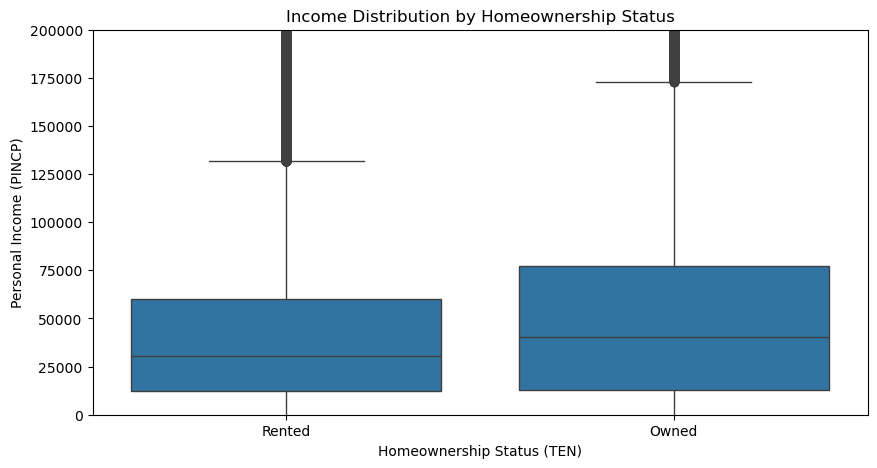

TEN
Owned     60159.624144
Rented    49726.215360
Name: PINCP, dtype: float64

In [34]:
# Filter data to exclude NaN values in TEN (homeownership status)
df_homeowners = df_merged.dropna(subset=["TEN"])

# Convert TEN to categorical for better readability
tenure_mapping = {1: "Owned", 2: "Rented"}
df_homeowners["TEN"] = df_homeowners["TEN"].map(tenure_mapping)

# Plot homeownership distribution by income group
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_homeowners, x="TEN", y="PINCP")
plt.ylim(0, 200000)  # Limit y-axis to avoid outliers skewing visualization
plt.xlabel("Homeownership Status (TEN)")
plt.ylabel("Personal Income (PINCP)")
plt.title("Income Distribution by Homeownership Status")
plt.show()

# Display average income for homeowners vs renters
df_homeowners.groupby("TEN")["PINCP"].mean()
